<a href="https://colab.research.google.com/github/ljzier/ST-554-repo/blob/main/ST_554_HW6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Linda Zier**

**ST 554**

**HW #6**

Part I

1. Below I have connected to the lahman_1871-2022.sqlite sqlite  database and then looked at all of the tables in the database.


In [4]:
# practice on querying a data base
import pandas as pd
import sqlite3
import numpy as np

#make the connection to the db
con = sqlite3.connect("lahman_1871-2022.sqlite")

get_schema = '''
    SELECT *
    FROM sqlite_schema
    WHERE type ='table'
    '''
df = pd.read_sql(get_schema, con)
print(df)

     type                 name             tbl_name  rootpage  \
0   table          AllstarFull          AllstarFull         2   
1   table          Appearances          Appearances         3   
2   table       AwardsManagers       AwardsManagers         4   
3   table        AwardsPlayers        AwardsPlayers         5   
4   table  AwardsShareManagers  AwardsShareManagers         6   
5   table   AwardsSharePlayers   AwardsSharePlayers         7   
6   table              Batting              Batting         8   
7   table          BattingPost          BattingPost         9   
8   table       CollegePlaying       CollegePlaying        10   
9   table             Fielding             Fielding        11   
10  table           FieldingOF           FieldingOF        12   
11  table      FieldingOFsplit      FieldingOFsplit        13   
12  table         FieldingPost         FieldingPost        14   
13  table           HallOfFame           HallOfFame        15   
14  table            Home


2. I've constructed a table of hall of fame pitchers that gives the
playerID and their total (sum) for GS, G, W, L, IPOuts, CG, SHO, and SV columns.

In [5]:
# Calculating total GS, G, W, L, IPOuts, CG, SHO, and SV for HOF pitchers
# G	Games	Total games played
# GS	Games Started	Games started as a pitcher
# W	Wins	Games won while pitching
# L	Losses	Games lost while pitching
# IPOuts	Innings Pitched (Outs)
# CG	Complete Games	Games pitched from start to finish
# SHO	Shutouts	Complete games with 0 runs allowed
# SV	Saves	Games finished while maintaining a lead
#-------------------------------------------------------

# see what columns are in Pitching table
#df=pd.read_sql("SELECT * FROM Pitching LIMIT 5", con)
#print(df.columns)

record = '''
    SELECT P.playerID, P.GS, P.G, P.W, P.L, P.IPouts, P.CG, P.SHO, P.SV FROM Pitching as P
    INNER JOIN HallOfFame as HOF ON P.playerID = HOF.playerID
    WHERE (HOF.inducted = 'Y')
    '''
df = pd.read_sql(record, con)

# Calculate total GS, G, W, L, IPOuts, CG, SHO, and SV for each hof pitcher
# I saved in a new database
df_pitching = df.groupby('playerID').agg(games_start=('GS', 'sum'), games=('G','sum'),
                                 wins=('W', 'sum'), losses=('L', 'sum'),ip_outs=('IPouts','sum'),
                                comp_games = ('CG', 'sum'), shutouts=('SHO', 'sum'),
                                 saves=('SV', 'sum')).reset_index()

print(df_pitching)

      playerID  games_start  games  wins  losses  ip_outs  comp_games  \
0    alexape01          599    696   373     208    15570         437   
1    ansonca01            0      3     0       1       12           0   
2    becklja01            1      1     0       1       12           0   
3    bendech01          334    459   212     127     9051         255   
4    blylebe01          685    692   287     250    14910         242   
..         ...          ...    ...   ...     ...      ...         ...   
103  willivi01          471    513   249     205    11988         388   
104  wrighge01            0      3     0       1       15           0   
105  wrighha01            8     36     4       4      301           0   
106   wynnea01          612    691   300     244    13692         290   
107  youngcy01          815    906   511     315    22068         749   

     shutouts  saves  
0          90     32  
1           0      1  
2           0      0  
3          40     34  
4       

3. For all of the hall of fame pitchers I've shown a table of their batting statistics. Namely, the
playerID and their total (sum) for AB, R, H, HR, RBI, BB, and SO.

In [6]:
# Creating a table for the following HOF pitchers and their stats included in the following:
#
# AB (At-Bats Allowed): The total number of official at-bats the pitcher has faced. This excludes walks, hit-by-pitches, and sacrifice hits.
# R (Runs Allowed): The total number of runs (both earned and unearned) that scored while the pitcher was in the game or charged to them.
# H (Hits Allowed): The total number of base hits (singles, doubles, triples, home runs) the pitcher has given up.
# HR (Home Runs Allowed): The total number of home runs the pitcher has given up.
# RBI (Runs Batted In Allowed): The total number of runs that scored due to a batter’s hit or action while the pitcher was on the mound.
# BB (Base on Balls/Walks Allowed): The total number of times the pitcher has walked an opposing batter.
# SO (Strikeouts/K): The total number of batters the pitcher has struck out. Note: In some databases, this may be listed as "K" instead of "SO".


# see what columns are in Batting table
dfb=pd.read_sql("SELECT * FROM Batting LIMIT 5", con)
print(dfb.columns)

record = """
    SELECT B.playerID, B.R, B.H, B.HR, B.RBI, B.BB, B.SO, B.AB FROM Pitching as P
    INNER JOIN Batting as B ON P.playerID = B.playerID
    INNER JOIN HallOfFame as HOF ON P.playerID = HOF.playerID
    WHERE (HOF.inducted = 'Y')
    """
df = pd.read_sql(record, con)

# Calculate total AB, R, H, HR, RBI, BB, and SO for each hof pitcher
# I saved in a new database
df_batting = df.groupby('playerID').agg(at_bats=('AB', 'sum'), runs=('R','sum'),
                                 hits=('H', 'sum'), homers=('HR', 'sum'),rbi=('RBI','sum'),
                                base_on = ('BB', 'sum'), strikes=('SO', 'sum')).reset_index()

print(df_batting)

Index(['playerID', 'yearID', 'stint', 'teamID', 'lgID', 'G', 'G_batting', 'AB',
       'R', 'H', '2B', '3B', 'HR', 'RBI', 'SB', 'CS', 'BB', 'SO', 'IBB', 'HBP',
       'SH', 'SF', 'GIDP', 'G_old'],
      dtype='object')
      playerID  at_bats  runs   hits  homers     rbi  base_on  strikes
0    alexape01    38010  3234   7938     231  3423.0     1617   5796.0
1    ansonca01    20562  3998   6870     194  4150.0     1968    660.0
2    becklja01     9551  1603   2938      87  1581.0      616    526.0
3    bendech01    18352  1632   3888      96  1856.0     1200   2288.0
4    blylebe01    10824   456   1416       0   600.0      120   4632.0
..         ...      ...   ...    ...     ...     ...      ...      ...
103  willivi01    19409  1391   3224      13  1092.0     1053   2587.0
104  wrighge01     5746  1330   1732      22   652.0      136    238.0
105  wrighha01     3252   732    896      16   452.0      148     56.0
106   wynnea01    39192  3128   8395     391  3979.0     3243   7590.0


4. I've merged the 2 tables below

In [7]:
# doing a table join of both
pitcher_stats=pd.merge(
    df_pitching,
    df_batting,
    on='playerID',
    how='inner'
)
print(pitcher_stats)

      playerID  games_start  games  wins  losses  ip_outs  comp_games  \
0    alexape01          599    696   373     208    15570         437   
1    ansonca01            0      3     0       1       12           0   
2    becklja01            1      1     0       1       12           0   
3    bendech01          334    459   212     127     9051         255   
4    blylebe01          685    692   287     250    14910         242   
..         ...          ...    ...   ...     ...      ...         ...   
103  willivi01          471    513   249     205    11988         388   
104  wrighge01            0      3     0       1       15           0   
105  wrighha01            8     36     4       4      301           0   
106   wynnea01          612    691   300     244    13692         290   
107  youngcy01          815    906   511     315    22068         749   

     shutouts  saves  at_bats  runs   hits  homers     rbi  base_on  strikes  
0          90     32    38010  3234   7938  

#Part II - Messing with Classes
5. In the previous homework we used a loop to repeatedly do simulations around the estimate of a sample
slope. The setup was:

*   Recall we assume the following model for SLR:
$$ Y_i = β_0 + β_1x_i + E_i $$
where the $E_i$ are assumed to be indendent and identically distributed from a standard Normal distribution
with mean 0 and variance $σ_2$ = 1.




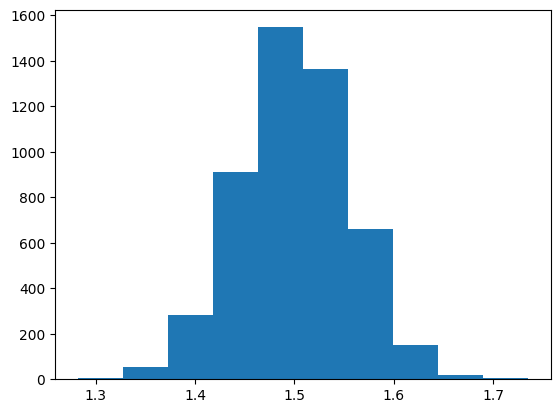

In [ ]:
#import some modules needed
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import default_rng
from sklearn import linear_model

rng = default_rng(32)
beta_0 = 7
beta_1 = 1.5
# get three 'values' of x at each integer from 0 to 10.
x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3)
n = len(x)

#prepare for the LR fit
reg = linear_model.LinearRegression()
#Create a reg object

#initialize array to save estimates (we don't need beta0 but I'm keeping it!)
beta_array = np.zeros(shape = (5000, 2))
for i in range(5000):
    #create the 'responses' modeled from the line plus a random deviation
    y = beta_0 + beta_1*x + rng.standard_normal(n)
    #find the least squares solutions and store them
    fit = reg.fit(x.reshape(-1, 1), y)
    beta_array[i, :] = [fit.intercept_, fit.coef_[0]]

#visualize the distribution of the slopedata
plt.hist(beta_array[:, 1])
plt.show()


In [ ]:
#estimate the probability we are larger than 1.65
bool_prob = beta_array[:, 1] > 1.65
bool_prob.mean()


np.float64(0.0038)

Here I am creating a class called SLR_slope_simulator to do the same thing.



*   Initializing the class using __init__ with arguments self, beta_0, beta_1, x, sigma, and seed

*   Adding these Methods:

– generate_data method that generates one dataset (returning x and y in whatever manner you
deem fit, i.e. as an array, two arrays, etc.)

– fit_slope method that takes in an x and y and fits the SLR model, returning the estimated
slope

– run_simulations method that takes in a number of simulations argument and uses the
generate_data() and fit_slope() methods within a for loop. This modifies the slopes attribute (replaces it with an array of slope estimates)

– plot_sampling_distribution method that checks if the slopes attribute has length greater
than 0. If it is, it produces a histogram of the slopes approximating the sampling distribution.

– find_prob method that takes in a value and a sided argument. It checks on the slopes
attribute as above. If the length is bigger than 0, it approximates the probability of being
“above”, “below”, or “two-sided”


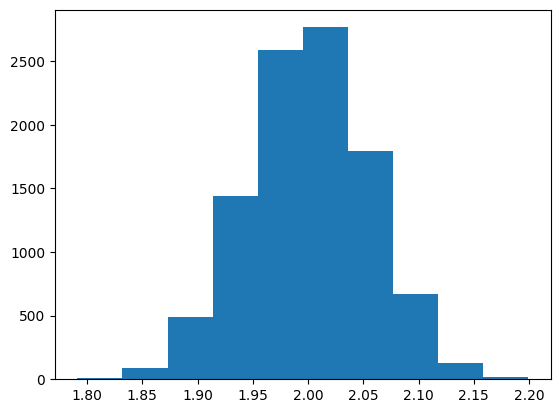

np.float64(1.9296)

In [7]:
# creating a slope simulator class

import matplotlib.pyplot as plt
import numpy as np
from numpy.random import default_rng
from sklearn import linear_model

class SLR_slope_simulator:
    # initializing
    def __init__(self, beta_0, beta_1, x, sigma, seed):
        self.beta_0 = beta_0
        self.beta_1 = beta_1
        self.sigma = sigma
        self.x = x
        self.n = len(x)
        self.rng = default_rng(seed)
        self.slopes = []

    # generate one dataset
    def generate_data(self):
        #create the 'responses' modeled from the line plus a random deviation
        y=self.beta_0 + self.beta_1*self.x + self.rng.standard_normal(self.n)
        return self.x, y

    # fit the SLR model and return slope
    def fit_slope(self, x, y):
        reg = linear_model.LinearRegression()
        fit=reg.fit(x.reshape(-1, 1), y)
        return fit.coef_[0]

    #take in n_sims and run the above 2
    def run_simulations(self, n_sims):
        for i in range(n_sims):
            x, y = self.generate_data()
            slope = self.fit_slope(x, y)
            self.slopes.append(slope)
        self.slopes = np.array(self.slopes) #convert to np array

    # produce histogram of slopes
    def plot_sampling_distribution(self):
        if len(self.slopes) == 0:
            print("run_simulations() must be called first")
            return
        plt.hist(self.slopes)
        plt.show()

    # find probability
    def find_prob(self, value, sided):
        if len(self.slopes) == 0:
            print("run_simulations() must be called first")
            return
        if sided == "above":
            prob = self.slopes > value
            return prob.mean()
        if sided == "below":
            prob = self.slopes< value
            return prob.mean()
        if sided == "two-sided":
            if value > np.median(self.x):
                prob = (self.slopes > value)
                return 2*prob.mean()
            if value <= np.median(self.x):
                prob = (self.slopes < value)
                return 2*prob.mean()


####################################################
# Using my newly made class

# variable assignments
beta_0 = 12
beta_1 = 2
x = np.array(list(np.linspace(start= 0, stop = 10, num = 11))*3)
sigma = 1
seed = 10
num_sims = 10000

# here's my new class
slope_sim = SLR_slope_simulator(beta_0, beta_1, x, sigma, seed)

#running simulations and plotting
slope_sim.run_simulations(num_sims)
slope_sim.plot_sampling_distribution()

# probability calc
slope_sim.find_prob(2.1, "two-sided")


Now I'm going to use my newly defined class:

– Creates an instance of the object with beta_0 = 12, beta_1 = 2, x = np.array(list(np.linspace(start
= 0, stop = 10, num = 11))*3), sigma = 1, and seed = 10

– Call your plot_sampling_distribution() method (this should return the error message)

– Run 10000 simulations

– Plot the sampling distribution

– Approximate the two-sided probability of being larger than 2.1

– Print out the value of the simulated slopes using the attributes

